In [1]:
import sys
print(sys.executable)

c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\python.exe


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10,6)
sns.set_style("whitegrid")

In [3]:
ruta = "../data/processed/datasetmodificado_clean.csv"

df = pd.read_csv(ruta)

df.head()

,AÑO,CÓDIGO_DEPARTAMENTO,DEPARTAMENTO,POBLACIÓN_5_16,TASA_MATRICULACIÓN_5_16,COBERTURA_NETA,COBERTURA_NETA_TRANSICIÓN,COBERTURA_NETA_PRIMARIA,COBERTURA_NETA_SECUNDARIA,COBERTURA_NETA_MEDIA,...,REPROBACIÓN,REPROBACIÓN_TRANSICIÓN,REPROBACIÓN_PRIMARIA,REPROBACIÓN_SECUNDARIA,REPROBACIÓN_MEDIA,REPITENCIA,REPITENCIA_TRANSICIÓN,REPITENCIA_PRIMARIA,REPITENCIA_SECUNDARIA,REPITENCIA_MEDIA
0,2013.0,27,Chocó,145133.0,79.59,79.59,55.47,82.73,44.28,18.43,...,6.56,0.14,88.62,8.37,4.38,0.15,0.14,0.16,0.11,0.06
1,2017.0,27,Chocó,145765.0,79.20,79.19,54.05,80.16,48.97,22.19,...,9.14,0.28,88.14,11.68,5.35,2.23,0.28,3.14,1.39,0.38
2,2016.0,50,Meta,219565.0,92.40,92.28,56.26,90.78,77.27,43.97,...,5.57,0.18,91.88,9.22,5.21,0.86,0.18,0.84,1.23,0.25
3,2013.0,68,Santander,419596.0,93.40,93.28,60.45,92.92,80.27,48.09,...,3.41,0.47,95.30,5.58,4.41,2.04,0.47,1.48,3.29,1.35
4,2015.0,17,Caldas,194108.0,78.90,78.86,52.47,74.53,69.24,43.55,...,8.20,0.80,90.65,12.14,6.34,2.18,0.80,1.55,3.58,1.65


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   AÑO                          31 non-null     float64
 1   CÓDIGO_DEPARTAMENTO          31 non-null     int64  
 2   DEPARTAMENTO                 31 non-null     object 
 3   POBLACIÓN_5_16               31 non-null     float64
 4   TASA_MATRICULACIÓN_5_16      31 non-null     float64
 5   COBERTURA_NETA               31 non-null     float64
 6   COBERTURA_NETA_TRANSICIÓN    31 non-null     float64
 7   COBERTURA_NETA_PRIMARIA      31 non-null     float64
 8   COBERTURA_NETA_SECUNDARIA    31 non-null     float64
 9   COBERTURA_NETA_MEDIA         31 non-null     float64
 10  COBERTURA_BRUTA              31 non-null     float64
 11  COBERTURA_BRUTA_TRANSICIÓN   31 non-null     float64
 12  COBERTURA_BRUTA_PRIMARIA     31 non-null     float64
 13  COBERTURA_BRUTA_SECUND

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
AÑO,31.0,2014.645161,1.780419,2011.00,2013.000,2015.00,2016.000,2017.00
CÓDIGO_DEPARTAMENTO,31.0,42.548387,23.896776,13.00,18.500,41.00,60.000,86.00
POBLACIÓN_5_16,31.0,237115.967742,106378.476178,88626.00,145695.000,217437.00,308924.500,492500.00
TASA_MATRICULACIÓN_5_16,31.0,85.805161,6.242095,75.40,80.035,86.80,90.335,97.80
COBERTURA_NETA,31.0,85.736774,6.209082,75.36,80.035,86.62,90.305,97.72
COBERTURA_NETA_TRANSICIÓN,31.0,54.878065,7.705715,35.59,51.660,55.82,59.245,71.03
COBERTURA_NETA_PRIMARIA,31.0,84.590323,6.535835,70.11,80.375,84.11,89.795,96.81
COBERTURA_NETA_SECUNDARIA,31.0,68.383871,9.784590,44.28,63.870,70.90,75.585,81.76
COBERTURA_NETA_MEDIA,31.0,36.974839,8.812109,18.43,30.465,39.36,43.725,48.36
COBERTURA_BRUTA,31.0,99.256452,6.708010,86.35,95.125,100.20,103.625,112.68


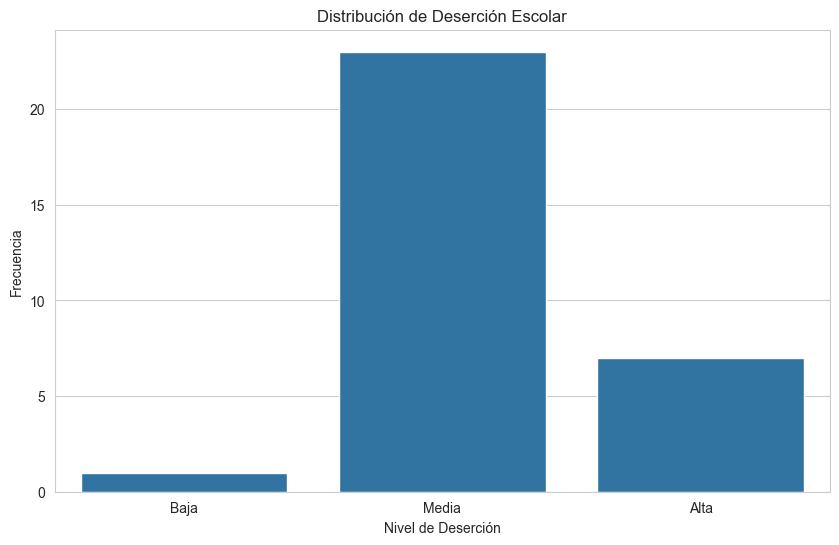

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Crear categorías de deserción
df["nivel_desercion"] = pd.cut(
    df["DESERCIÓN"],
    bins=[0, 2, 5, 100],
    labels=["Baja", "Media", "Alta"]
)

# Gráfico
sns.countplot(
    data=df,
    x="nivel_desercion"
)

plt.title("Distribución de Deserción Escolar")
plt.xlabel("Nivel de Deserción")
plt.ylabel("Frecuencia")

plt.show()

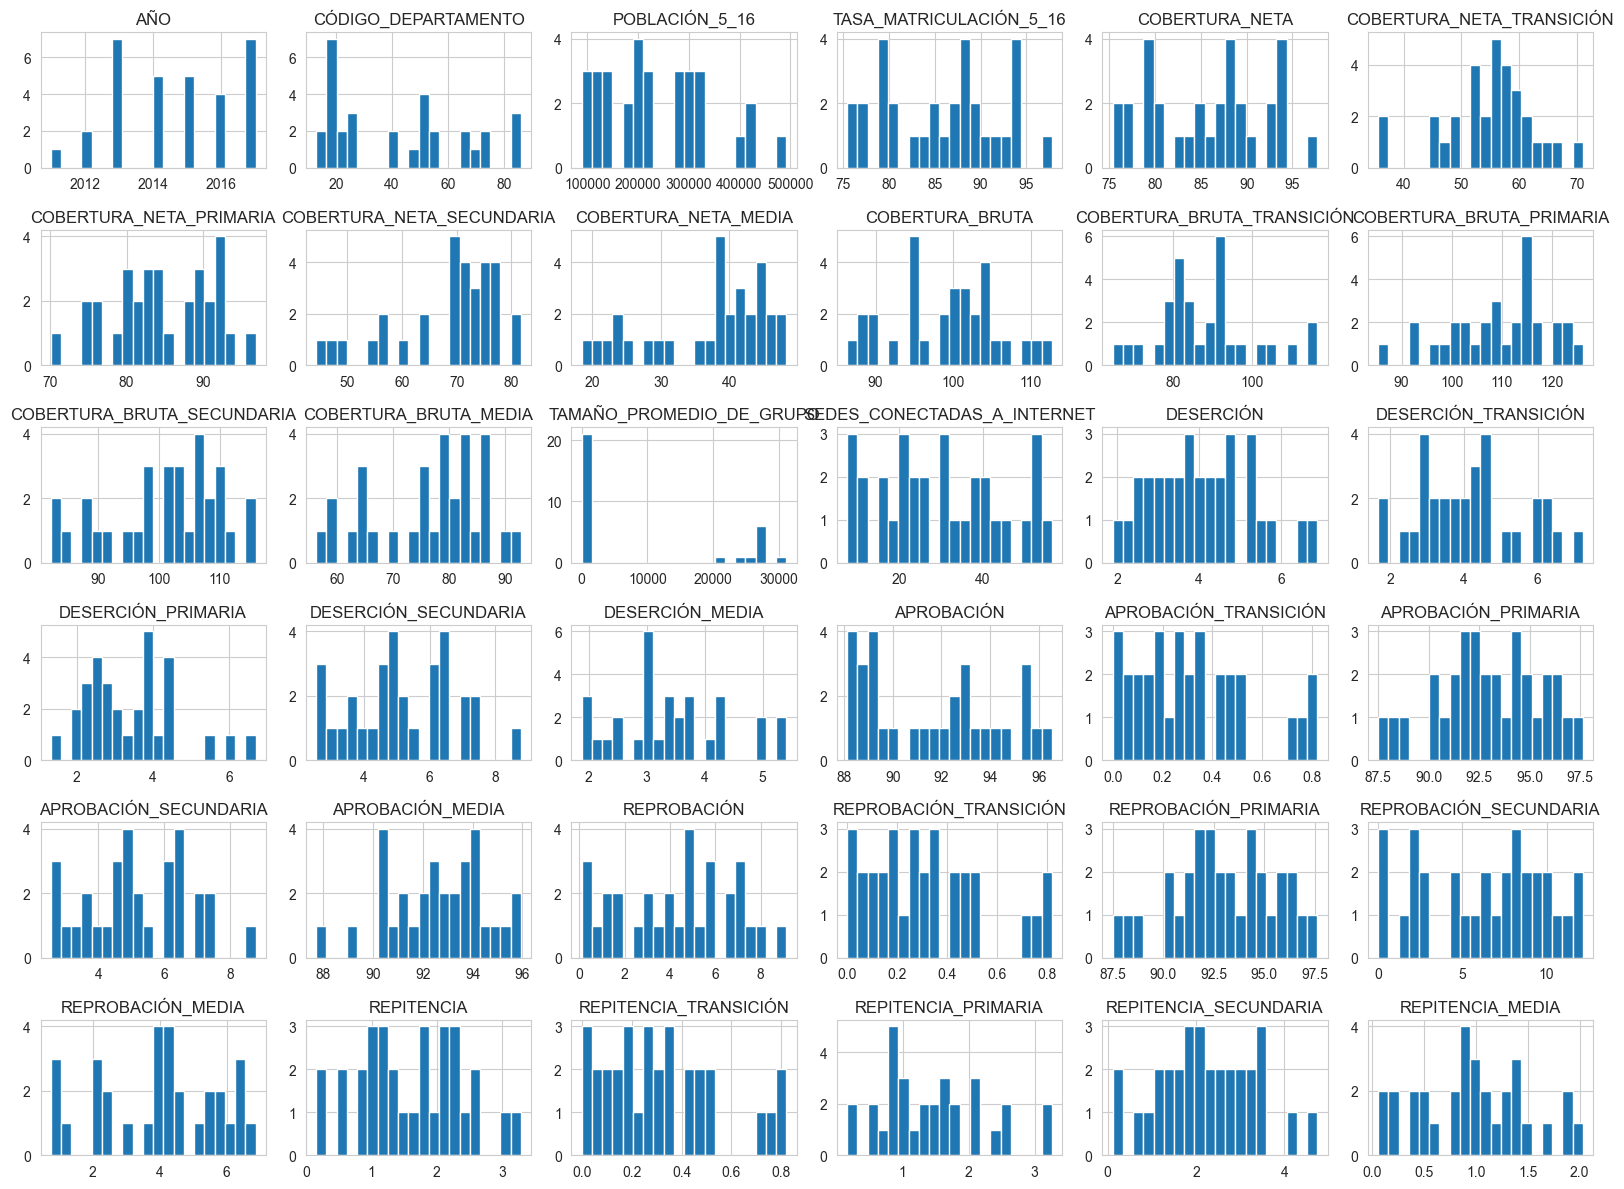

In [7]:
df.hist(
    bins=20,
    figsize=(16,12)
)

plt.tight_layout()

plt.show()

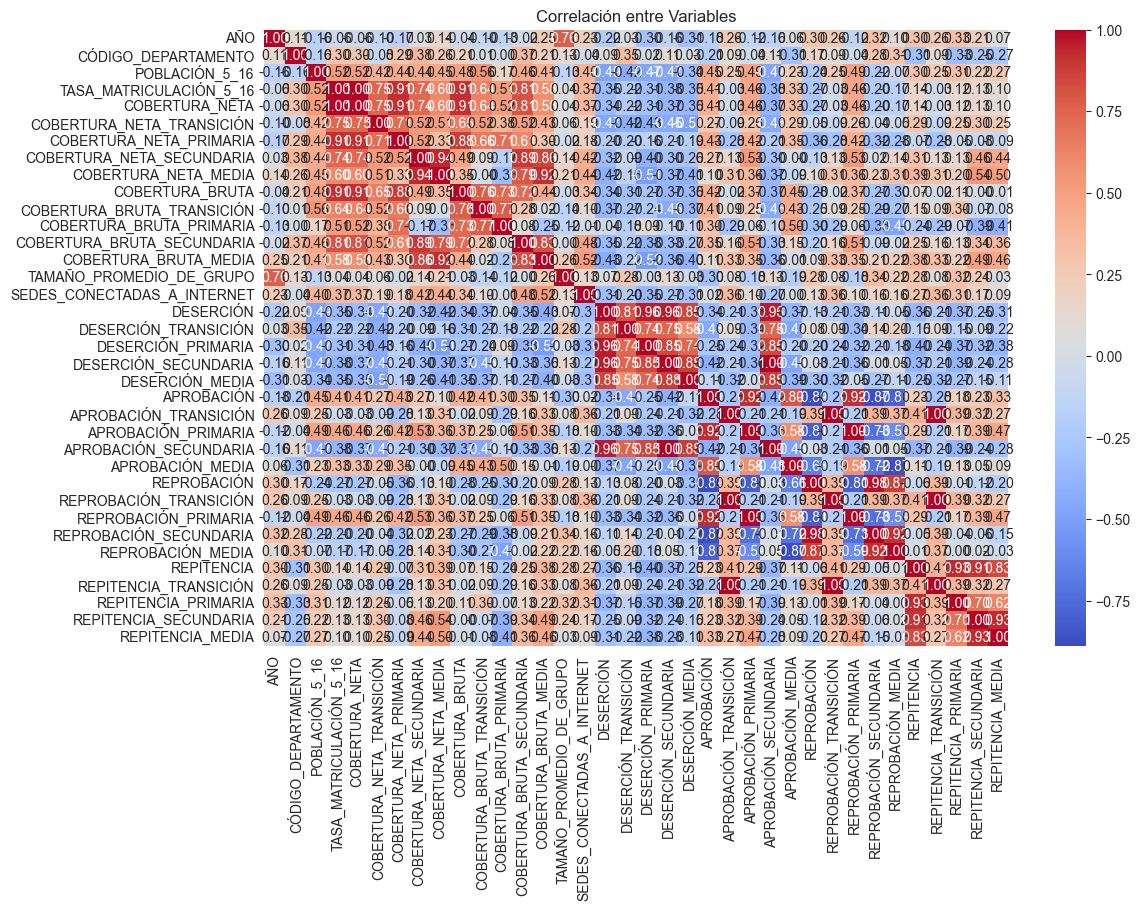

In [8]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlación entre Variables")

plt.show()

In [10]:
corr_desercion = corr["DESERCIÓN"].sort_values(
    ascending=False
)

corr_desercion

DESERCIÓN                      1.000000
APROBACIÓN_SECUNDARIA          0.960471
DESERCIÓN_SECUNDARIA           0.960471
DESERCIÓN_PRIMARIA             0.956811
DESERCIÓN_MEDIA                0.853364
DESERCIÓN_TRANSICIÓN           0.811561
CÓDIGO_DEPARTAMENTO            0.091160
TAMAÑO_PROMEDIO_DE_GRUPO       0.067630
COBERTURA_BRUTA_PRIMARIA      -0.043914
REPROBACIÓN_MEDIA             -0.052332
REPROBACIÓN_SECUNDARIA        -0.109333
REPROBACIÓN                   -0.126255
COBERTURA_NETA_PRIMARIA       -0.201130
REPITENCIA_TRANSICIÓN         -0.207491
REPROBACIÓN_TRANSICIÓN        -0.207491
APROBACIÓN_TRANSICIÓN         -0.207491
AÑO                           -0.223399
REPITENCIA_SECUNDARIA         -0.250196
REPITENCIA_MEDIA              -0.307446
SEDES_CONECTADAS_A_INTERNET   -0.314668
COBERTURA_NETA_SECUNDARIA     -0.321694
APROBACIÓN_PRIMARIA           -0.330407
REPROBACIÓN_PRIMARIA          -0.330407
COBERTURA_BRUTA               -0.342890
APROBACIÓN                    -0.344015


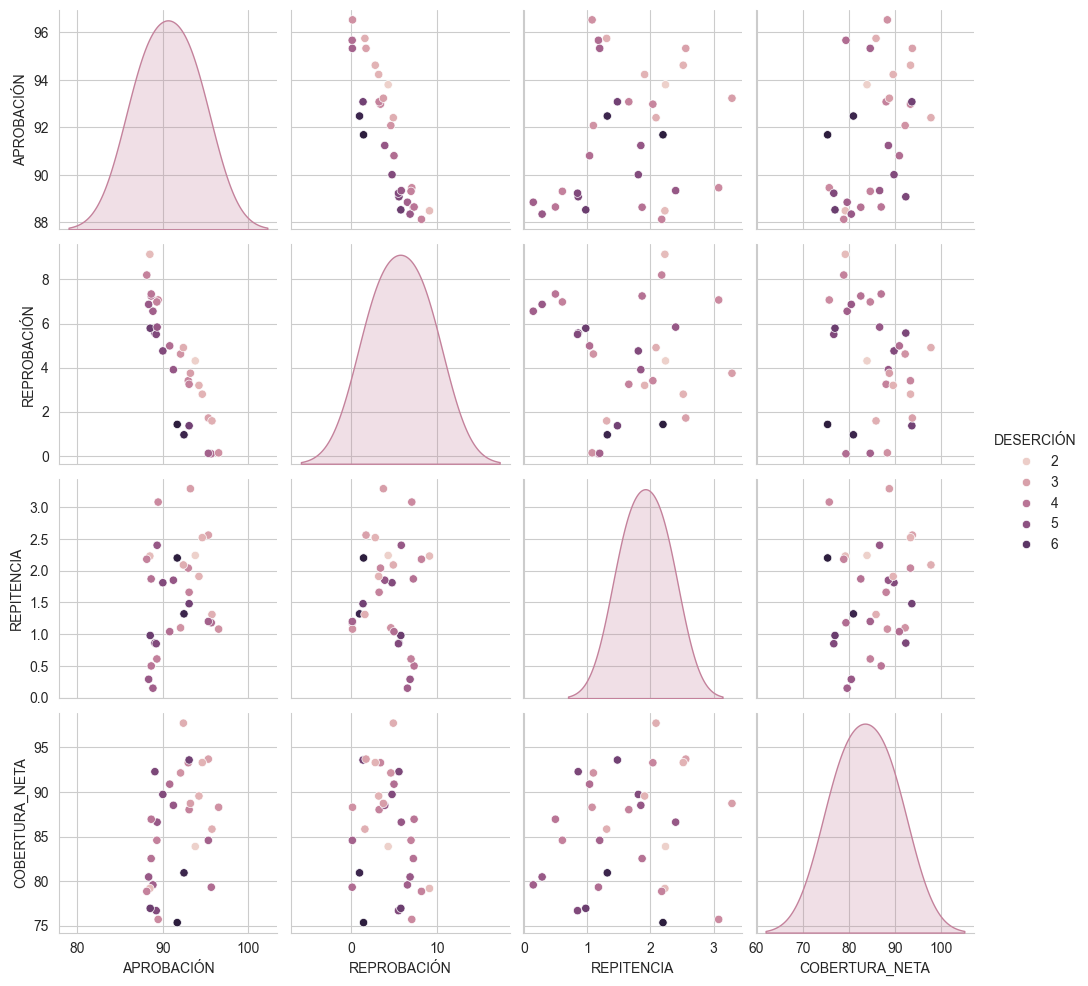

In [13]:
variables = [
    "DESERCIÓN",
    "APROBACIÓN",
    "REPROBACIÓN",
    "REPITENCIA",
    "COBERTURA_NETA"
]

sns.pairplot(
    df[variables],
    hue="DESERCIÓN"
)

plt.show()

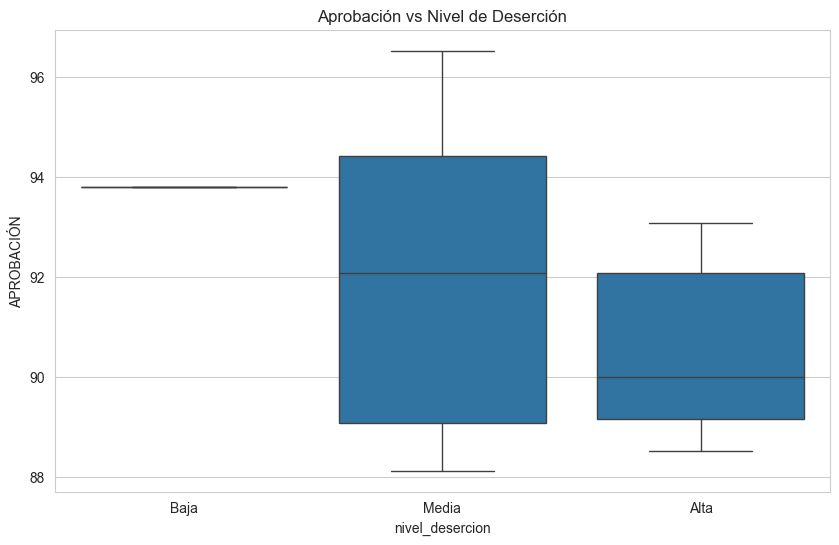

In [14]:
# Boxplot
sns.boxplot(
    data=df,
    x="nivel_desercion",
    y="APROBACIÓN"
)
plt.title("Aprobación vs Nivel de Deserción")
plt.show()

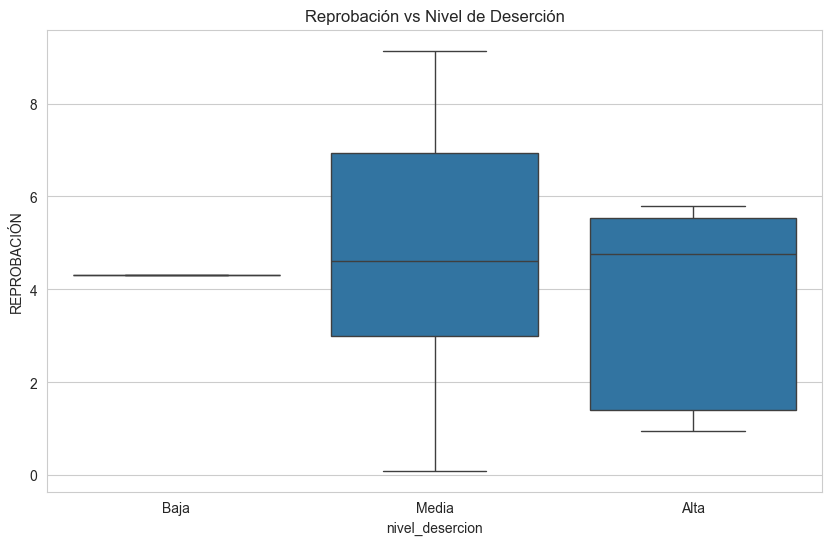

In [17]:
# Boxplot
sns.boxplot(
    data=df,
    x="nivel_desercion",
    y="REPROBACIÓN"
)
plt.title("Reprobación vs Nivel de Deserción")
plt.show()

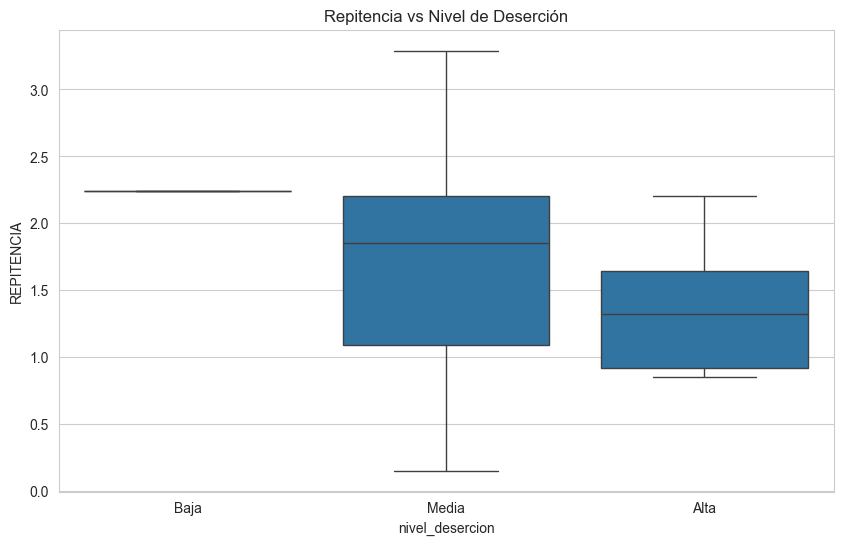

In [18]:
# Boxplot
sns.boxplot(
    data=df,
    x="nivel_desercion",
    y="REPITENCIA"
)
plt.title("Repitencia vs Nivel de Deserción")
plt.show()

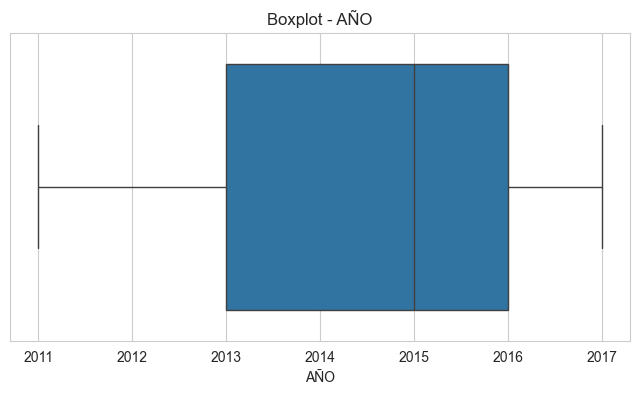

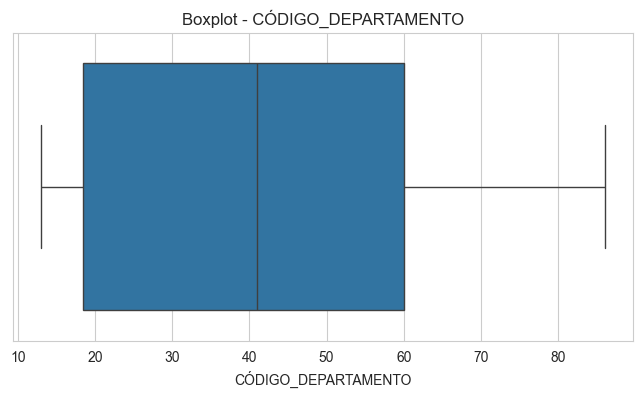

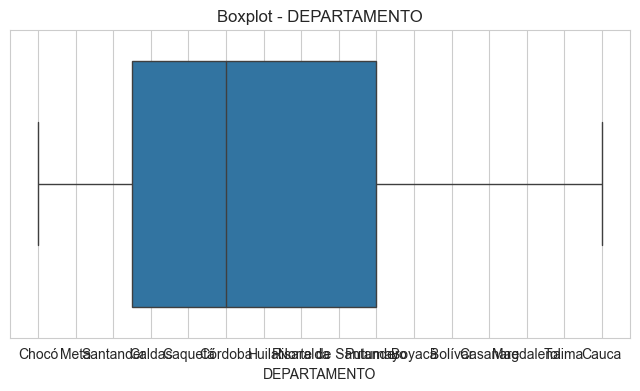

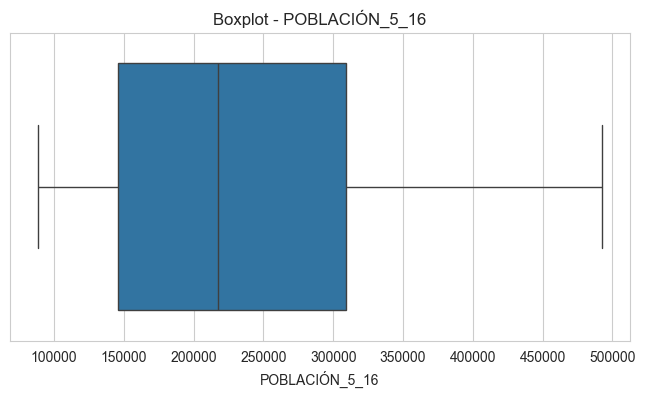

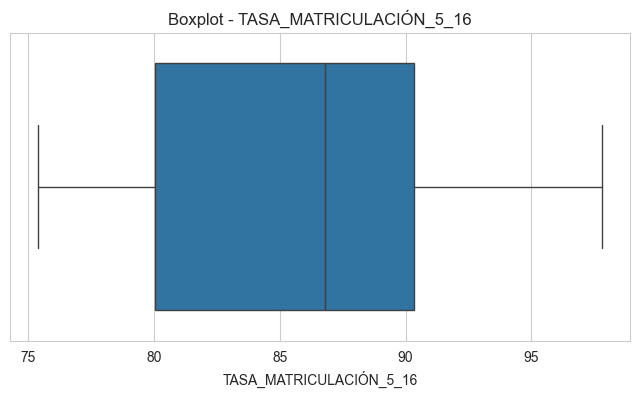

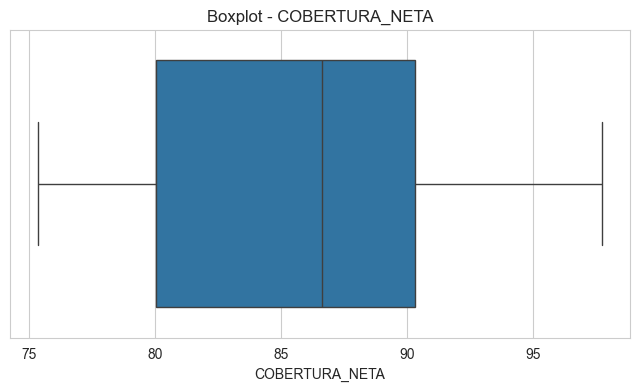

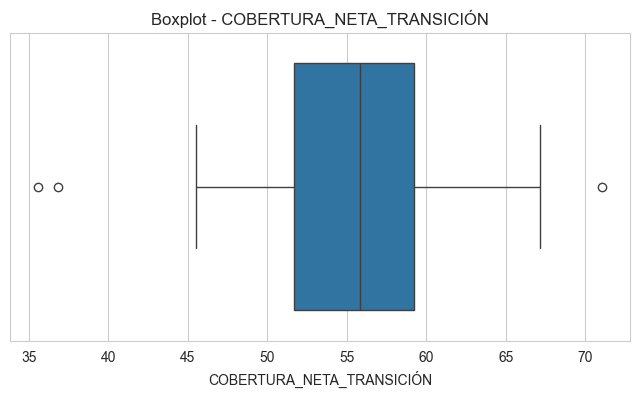

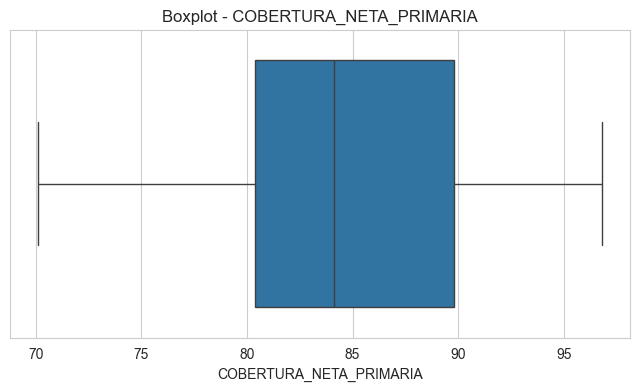

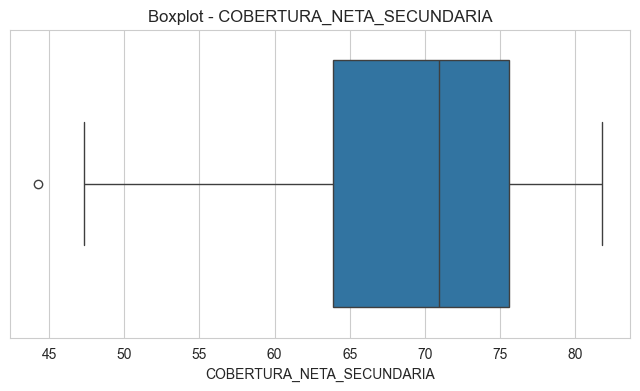

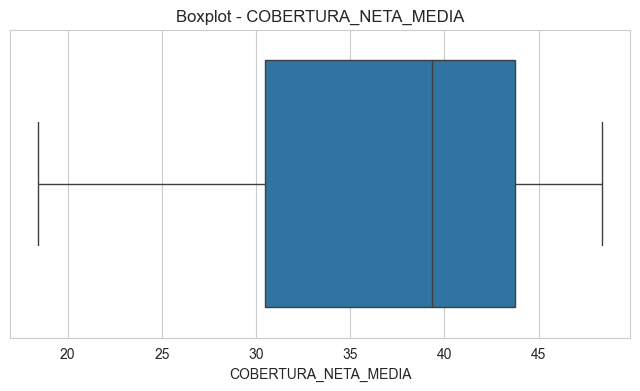

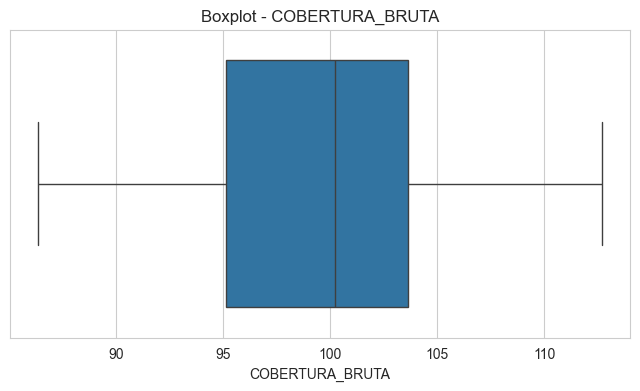

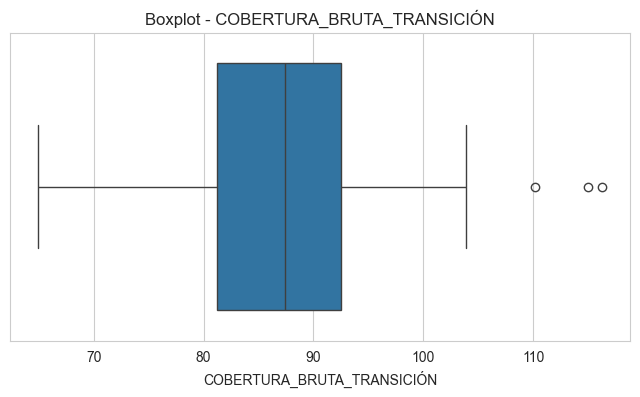

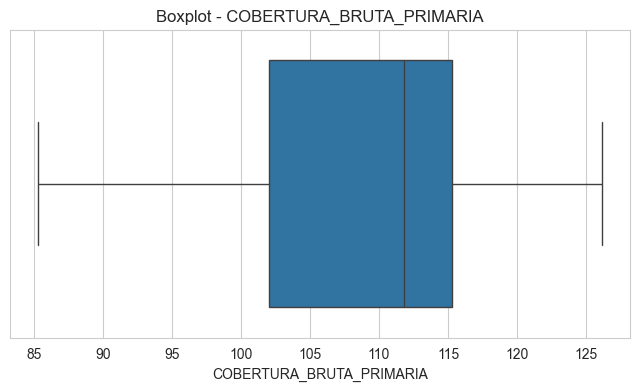

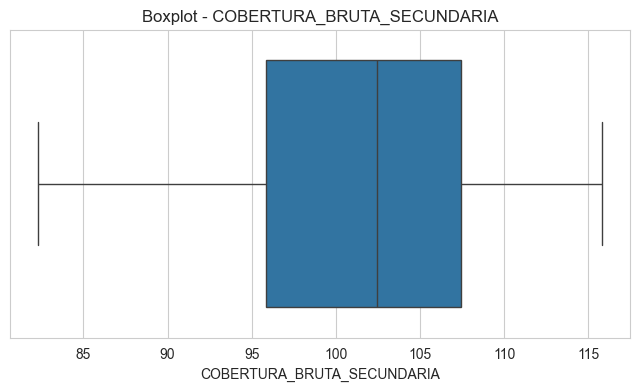

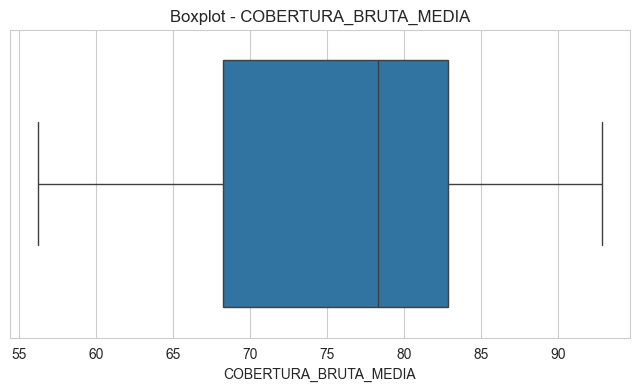

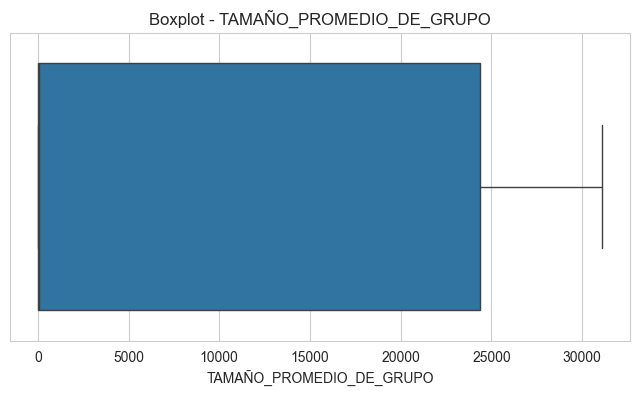

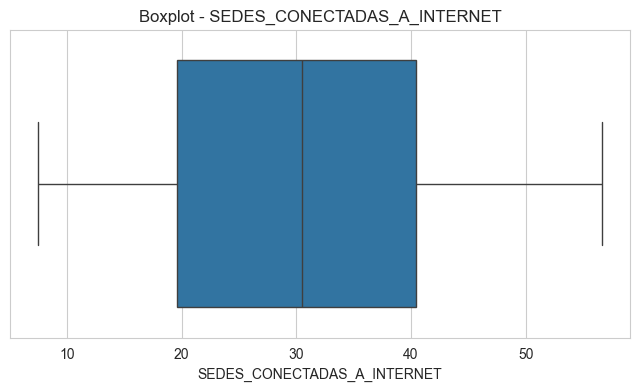

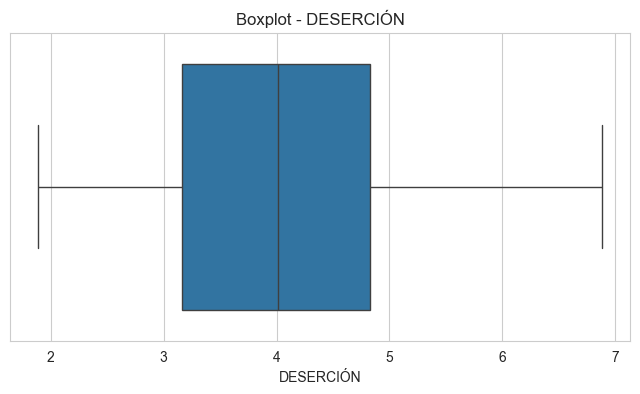

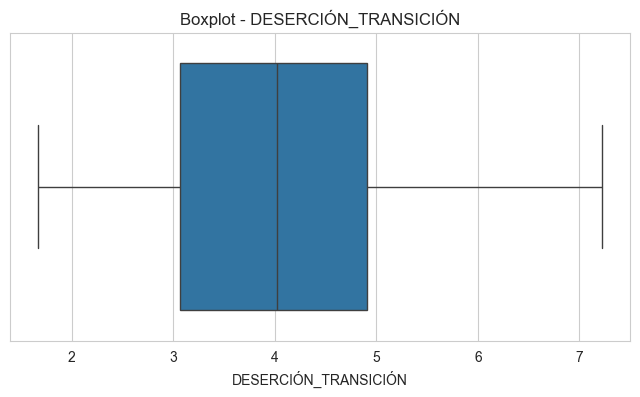

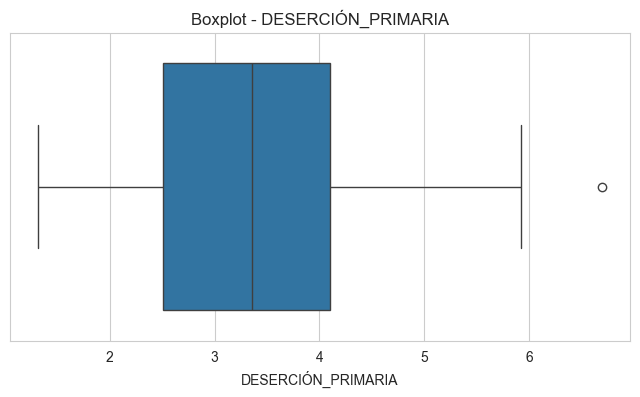

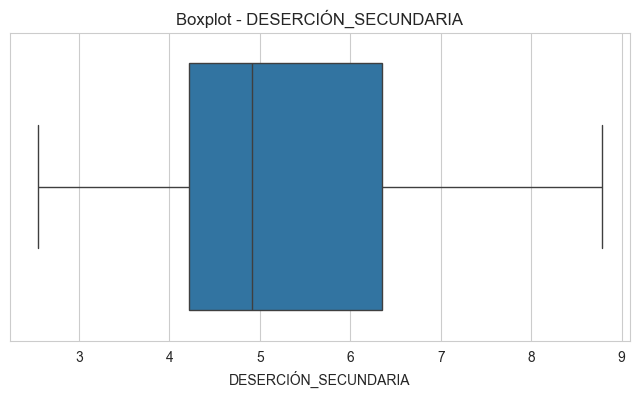

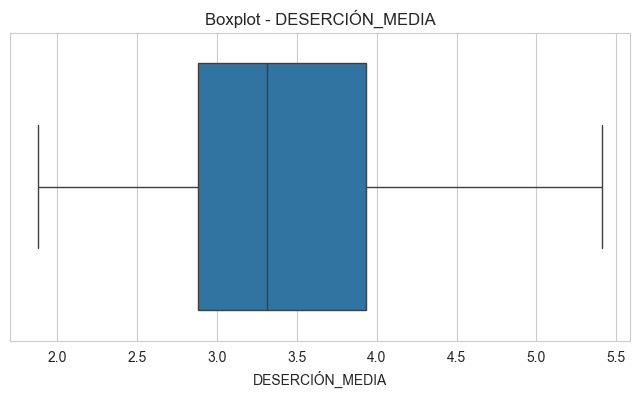

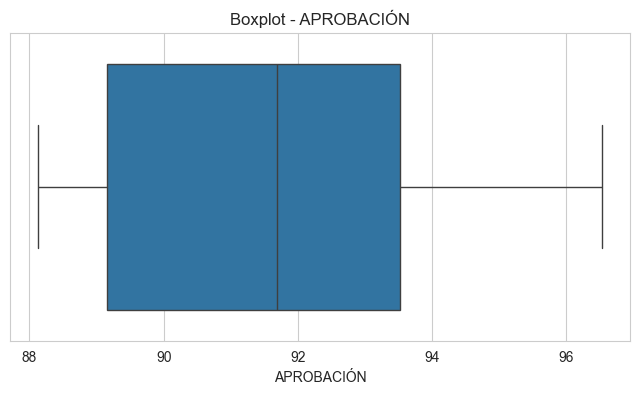

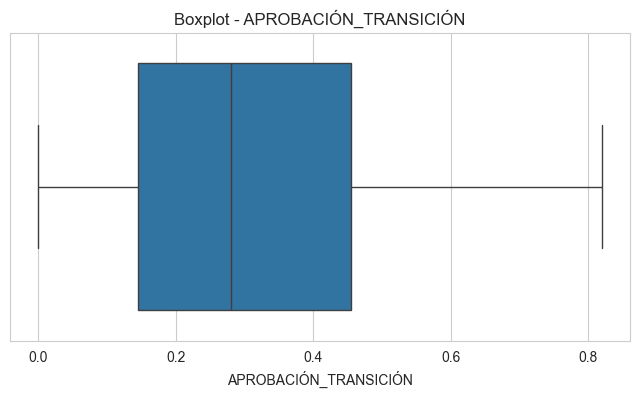

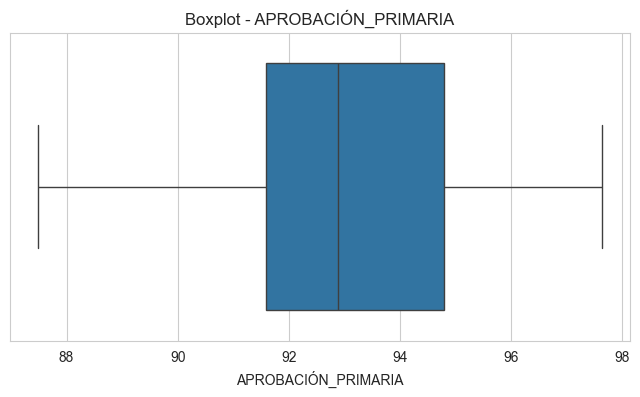

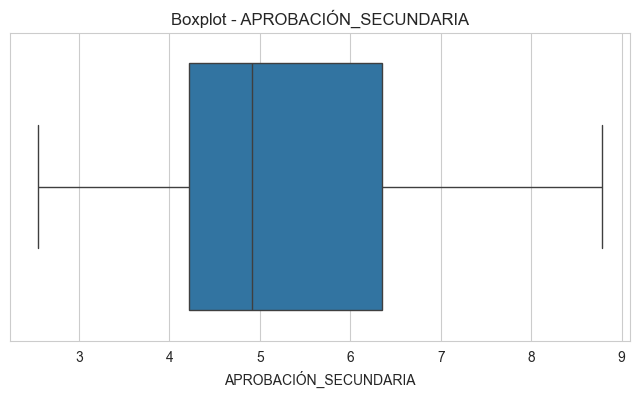

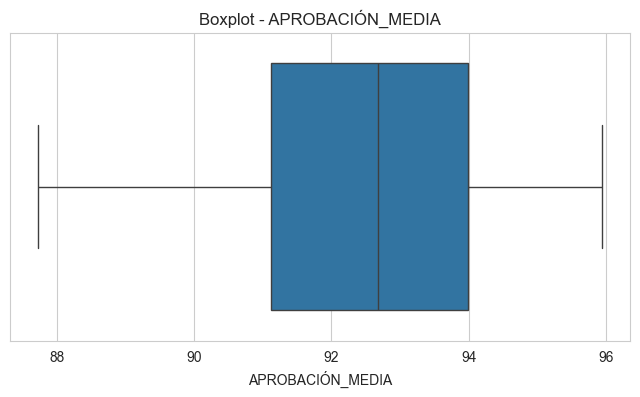

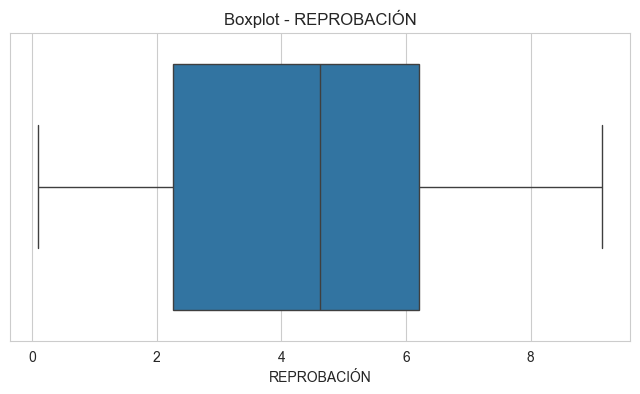

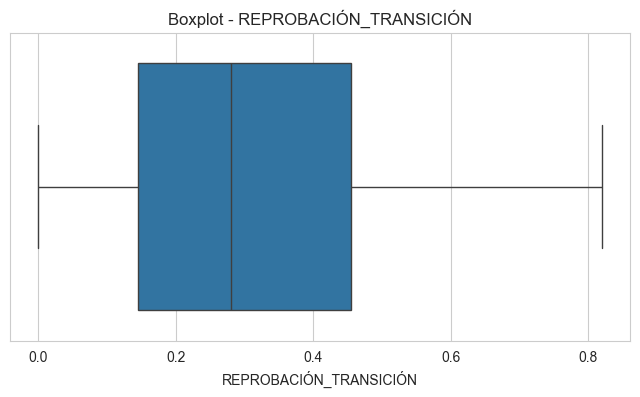

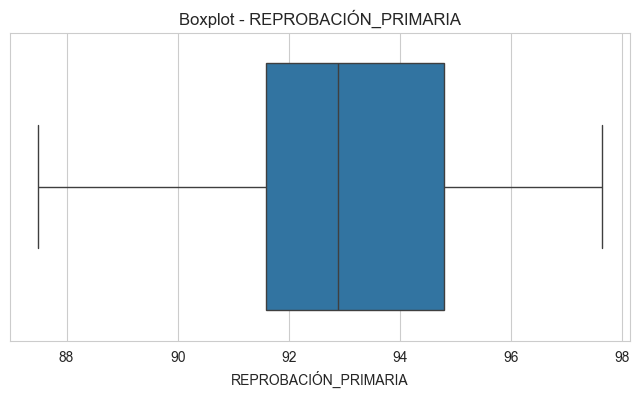

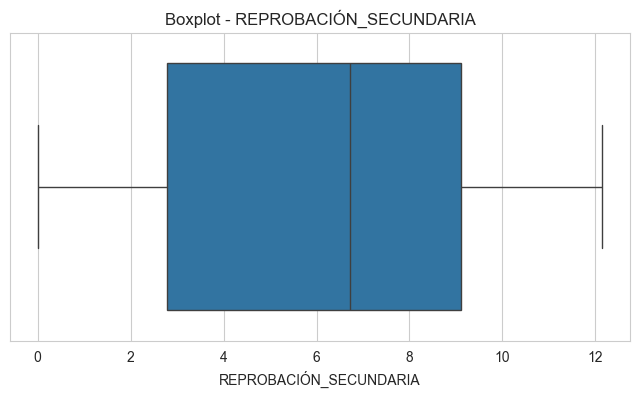

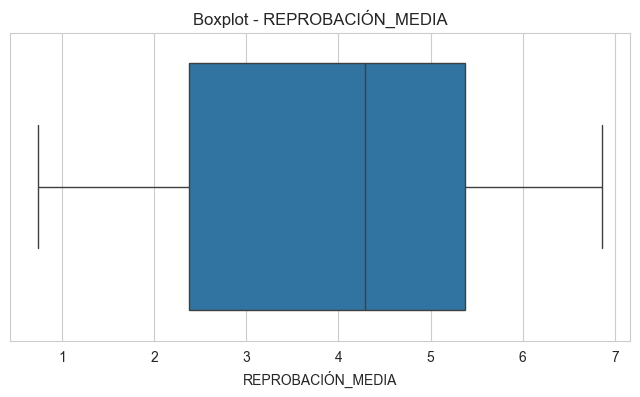

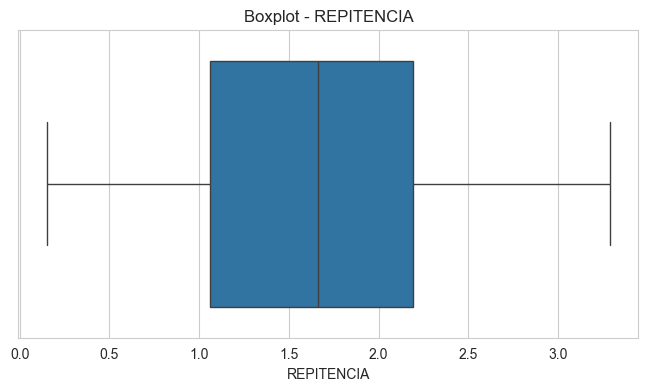

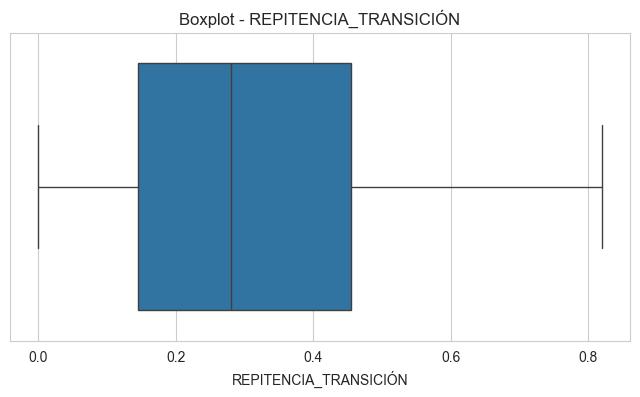

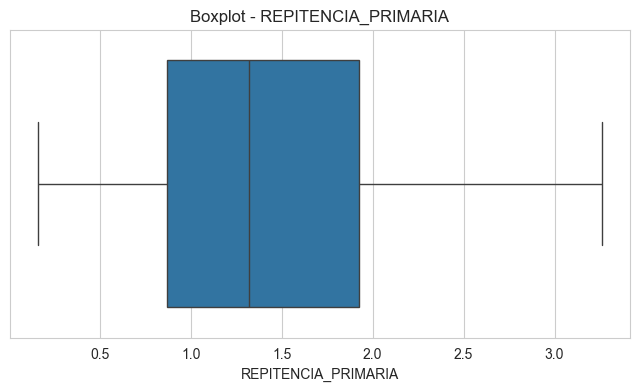

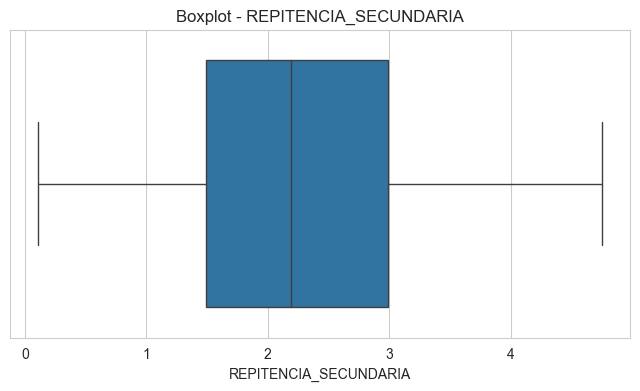

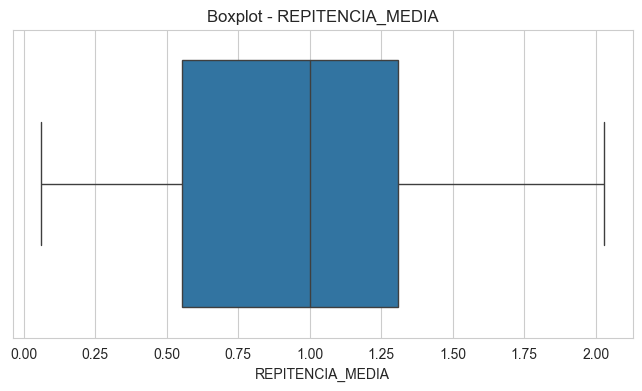

In [19]:
for columna in df.columns[:-1]:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[columna])

    plt.title(f"Boxplot - {columna}")

    plt.show()

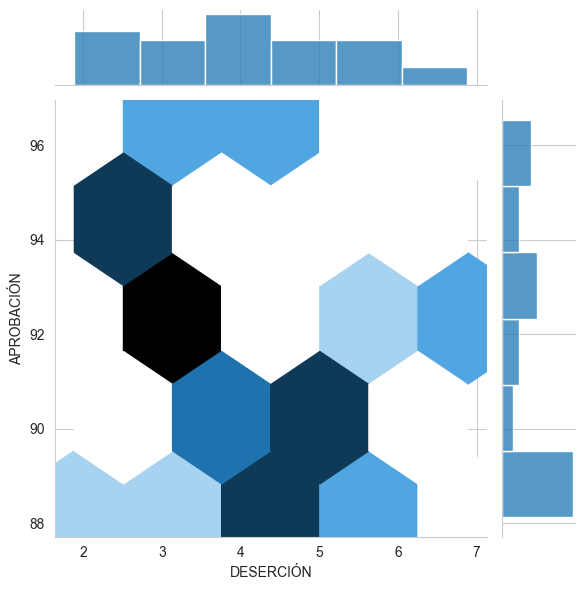

In [20]:
sns.jointplot(
    data=df,
    x="DESERCIÓN",
    y="APROBACIÓN",
    kind="hex"
)

plt.show()